In [1]:
# import dependencies
from utils import *

In [2]:
# set parameters (change manually if needed)
all_feat = False # set True to plot all edges, False to plot only batches' maximums
explicit_bias = False
models = ['GraphTransformer', 'GraphiT', 'SAN']
datasets = ['ZINC', ('TOX21','ogbg-moltox21'), 'PROTEINS']

In [4]:
# # set parameters (change manually if needed)
# all_feat = True # set True to plot all edges, False to plot only batches' maximums
# explicit_bias = False
# models = ['GraphTransformer', 'GraphTransformer', 'SAN']
# datasets = ['ZINC', 'ZINC', 'PROTEINS']

GraphTransformer ZINC
GraphTransformer ('TOX21', 'ogbg-moltox21')
GraphTransformer PROTEINS
GraphiT ZINC
GraphiT ('TOX21', 'ogbg-moltox21')
GraphiT PROTEINS
SAN ZINC
SAN ('TOX21', 'ogbg-moltox21')
SAN PROTEINS
out/plots/base_vs_train/Edge_features_ratio_sparse_NoPE_BN_MixBias_Edge_batch_edgemed.png


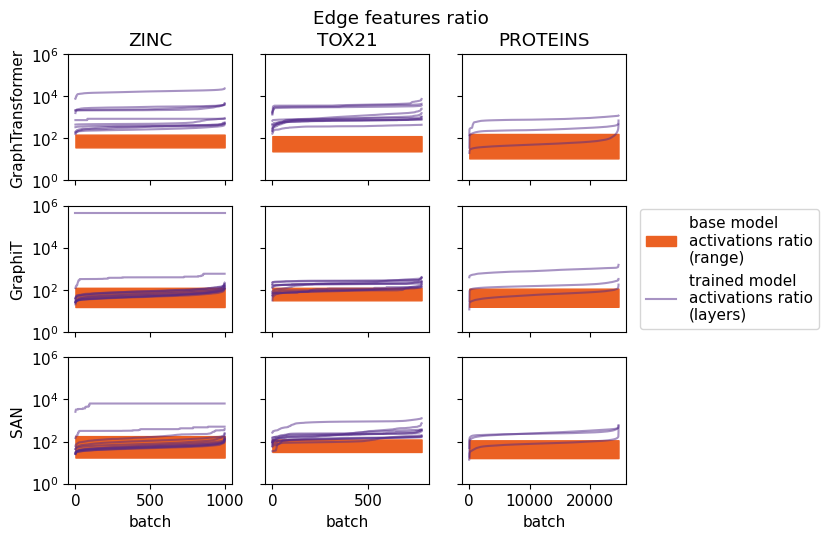

In [3]:
# generate plots
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams.update({'font.size': 11})
batch_median = False # false to normalize by edge median, default false
plot_threshold = False
mm = {'GT': 'Graph Transformer', ('TOX21','ogbg-moltox21'): 'TOX21'} # map model name in plot
title = 'Edge features ratio'
xlabel = 'edge' if all_feat else 'batch'
name = '_'.join(title.replace('/','over').split() + ['sparse', 'NoPE', 'BN', 'ExplicitBias' if explicit_bias else 'MixBias', 'Edge', 'edge' if all_feat else 'batch', 'batchmed' if batch_median else 'edgemed'])

scale = 6
w = 4.7/4
h = 3.1/3
fig, axs = plt.subplots(
    len(models), 
    len(datasets), 
    layout='constrained', 
    figsize=(0.4*w*len(datasets)*scale, 0.3*len(models)*scale),
    sharex='none' if all_feat else 'col',
    sharey='row'
)

a = None
for i,m in enumerate(models):
    for j,d in enumerate(datasets):
        if True:
            try:
                print(m, d)
                axs[i,j].set_ylim(1,1e6)
                axs[i,j].set_yscale('log')
                cspec = (m, d, 'sparse', ('NoPE','no_pe', 'none'), 'BN', 'NoBias', 'Edge', ('Escore',), 'base', -1)
                a = load_spec(cspec)
                plot2a(a, feat='e', axis=axs[i,j], title=None, legend=False, batch_median=batch_median, spec=cspec, all_feat=all_feat)
                del a
                if explicit_bias:
                    cspec = (m, d, 'sparse', ('NoPE','no_pe', 'none'), 'BN', 'ExplicitBias', 'Edge', 'train', -1)
                else:
                    cspec = (m, d, 'sparse', ('NoPE','no_pe', 'none'), 'BN', 'NoBias', 'Edge', 'train', -1)
                a = load_spec(cspec)
                plot2(a, feat='e', axis=axs[i,j], title=None, legend=False, batch_median=batch_median, spec=cspec, alpha=0.5, all_feat=all_feat, plot_threshold=plot_threshold)
                del a
            except Exception as e:
                print(cspec, e)
for i,m in enumerate(models):
    axs[i,0].set_ylabel(mm.get(m,m))
for j,d in enumerate(datasets):
    axs[0,j].set_title(mm.get(d,d))
    axs[i,j].set_xlabel(xlabel)
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right')
fig.suptitle(title)
for i in range(len(models)):
    for j in range(len(datasets)):
        p = axs[i,j].get_position()
        axs[i,j].set_position([p.x0/w, p.y0*h, p.width/w, p.height*h])

pathlib.Path('out/plots/base_vs_train').mkdir(parents=True, exist_ok=True)
print(f'out/plots/base_vs_train/{name}.png')
fig.savefig(f'out/plots/base_vs_train/{name}.pdf', format='pdf')
fig.savefig(f'out/plots/base_vs_train/{name}.png')


In [ ]:
# generate plots
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams.update({'font.size': 11})
batch_median = False # false to normalize by edge median, default false
plot_threshold = False
mm = {'GT': 'Graph Transformer'} # map model name in plot
title = 'Edge features ratio'
xlabel = 'edge' if all_feat else 'batch'
name = '_'.join(title.replace('/','over').split() + ['sparse', 'NoPE', 'BN', 'ExplicitBias' if explicit_bias else 'MixBias', 'Edge', 'edge' if all_feat else 'batch', 'batchmed' if batch_median else 'edgemed'])

scale = 6
w = 4.7/4
h = 3.1/3
fig, axs = plt.subplots(
    len(models), 
    len(datasets), 
    layout='constrained', 
    figsize=(0.4*w*len(datasets)*scale, 0.3*len(models)*scale),
    sharex='none' if all_feat else 'col',
    sharey='row'
)

a = None
for i,m in enumerate(models):
    for j,d in enumerate(datasets):
        if True:
            try:
                axs[i,j].set_ylim(1,1e6)
                axs[i,j].set_yscale('log')
                cspec = (m, d, 'sparse', 'NoPE', 'BN', 'NoBias', 'Edge', ('Escore',), 'base', 0)
                a = load_spec(cspec)
                plot2a(a, feat='e', axis=axs[i,j], title=None, legend=False, batch_median=batch_median, spec=cspec, all_feat=all_feat)
                del a
                if explicit_bias:
                    cspec = (m, d, 'sparse', 'NoPE', 'BN', 'ExplicitBias', 'Edge', ('Escore',), 'train', 0)
                else:
                    cspec = (m, d, 'sparse', 'NoPE', 'BN', 'NoBias', 'Edge', ('Escore',), 'train', 0)
                a = load_spec(cspec)
                plot2(a, feat='e', axis=axs[i,j], title=None, legend=False, batch_median=batch_median, spec=cspec, alpha=0.5, all_feat=all_feat, plot_threshold=plot_threshold)
                del a
            except Exception as e:
                print(cspec, e)
for i,m in enumerate(models):
    axs[i,0].set_ylabel(mm.get(m,m))
for j,d in enumerate(datasets):
    axs[0,j].set_title(d)
    axs[i,j].set_xlabel(xlabel)
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right')
fig.suptitle(title)
for i in range(len(models)):
    for j in range(len(datasets)):
        p = axs[i,j].get_position()
        axs[i,j].set_position([p.x0/w, p.y0*h, p.width/w, p.height*h])

pathlib.Path('out/plots/base_vs_train').mkdir(parents=True, exist_ok=True)
print(f'out/plots/base_vs_train/{name}.png')
fig.savefig(f'out/plots/base_vs_train/{name}.pdf', format='pdf')
fig.savefig(f'out/plots/base_vs_train/{name}.png')
